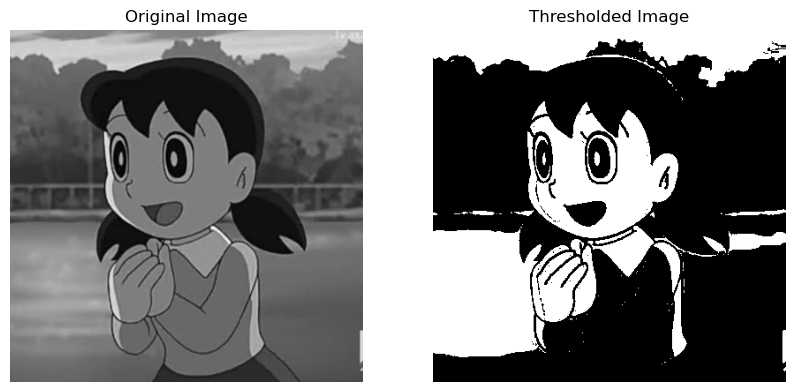

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale (basic I/O)
img = cv2.imread(r"C:\Users\rithi\Downloads\shizuka.jpg", cv2.IMREAD_GRAYSCALE)

# Set a threshold value (you can change this based on your needs)
thr = 110

# Create an empty array to store the thresholded result (same size as original image)
bin = np.zeros_like(img)

# Manual thresholding (looping through each pixel)
for i in range(img.shape[0]):  # Traverse through rows
    for j in range(img.shape[1]):  # Traverse through columns
        # Apply threshold: if pixel intensity is greater than threshold_value, set it to 255, else 0
        if img[i, j] > thr:
            bin[i, j] = 255  # Set to white (foreground)
        else:
            bin[i, j] = 0    # Set to black (background)

# Display the result
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.axis("off")
plt.subplot(122), plt.imshow(bin, cmap='gray'), plt.title('Thresholded Image')
plt.axis("off")
plt.show()


Initial centroids: [238, 92, 147]
Iteration 1, Updated centroids: [198, 76, 148]
Iteration 2, Updated centroids: [187, 70, 130]
Iteration 3, Updated centroids: [183, 65, 122]
Iteration 4, Updated centroids: [179, 55, 114]
Iteration 5, Updated centroids: [174, 47, 108]
Iteration 6, Updated centroids: [168, 40, 104]
Iteration 7, Updated centroids: [163, 37, 101]
Iteration 8, Updated centroids: [160, 35, 100]
Iteration 9, Updated centroids: [159, 34, 99]
Iteration 10, Updated centroids: [158, 33, 98]


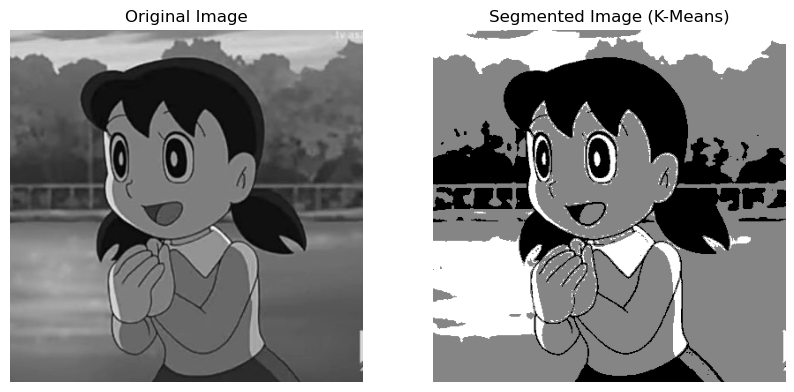

In [38]:
import random
rows, cols = img.shape

# Reshape the image into a 1D array of pixels
pixels = img.reshape((-1,))  # Flatten image into a 1D array

# Number of clusters (K)
K = 3
# Randomly initialize K centroids (between 0 and 255 intensity values)
centroids = [random.randint(0, 255) for _ in range(K)]
print(f"Initial centroids: {centroids}")

# K-Means Parameters
max_iterations = 10
tolerance = 1e-4  # Stop early if centroids converge

# Main K-Means loop
for iteration in range(max_iterations):
    # Step 1: Assign each pixel to the nearest centroid
    clusters = {i: [] for i in range(K)}  # Dictionary to store cluster members
    for pixel in pixels:
        # Calculate distances from current pixel to each centroid
        distances = [abs(pixel - centroid) for centroid in centroids]
        # Find the nearest centroid and assign the pixel to the corresponding cluster
        nearest_centroid_index = distances.index(min(distances))
        clusters[nearest_centroid_index].append(pixel)

    # Step 2: Update centroids by computing the mean of pixels in each cluster
    new_centroids = []
    for cluster_index, cluster_pixels in clusters.items():
        if cluster_pixels:  # Avoid division by zero
            new_centroids.append(sum(cluster_pixels) // len(cluster_pixels))
        else:
            # If a cluster is empty, randomly initialize its centroid again
            new_centroids.append(random.randint(0, 255))

    print(f"Iteration {iteration + 1}, Updated centroids: {new_centroids}")

    # Step 3: Check for convergence (if centroids do not change significantly)
    if all(abs(new_centroids[i] - centroids[i]) < tolerance for i in range(K)):
        print(f"Converged after {iteration + 1} iterations.")
        break

    centroids = new_centroids  # Update centroids for the next iteration

# Step 4: Create a segmented image based on final centroids
segmented_pixels = [centroids[nearest_centroid_index] for nearest_centroid_index in [
    min(range(K), key=lambda i: abs(pixel - centroids[i])) for pixel in pixels
]]
segmented_image = np.array(segmented_pixels).reshape((rows, cols))

# Display the original and segmented images
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.axis("off")
plt.subplot(122), plt.imshow(segmented_image, cmap='gray'), plt.title('Segmented Image (K-Means)')
plt.axis("off")
plt.show()


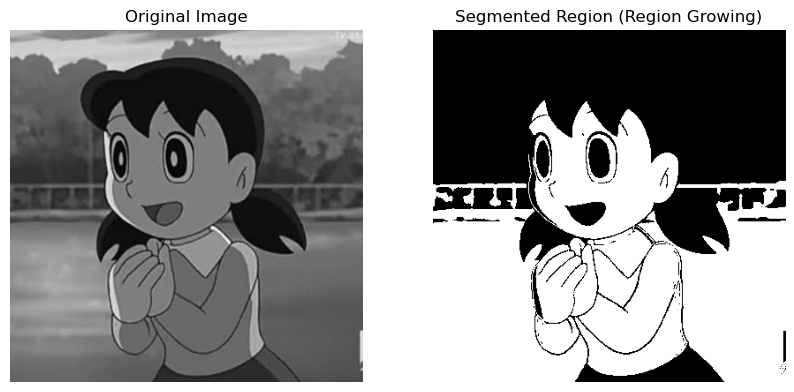

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import cv2  # For image reading only

# Load the image in grayscale

rows, cols = image.shape

# Initialize parameters
seed_point = (150, 150)  # Seed point to start region growing
threshold = 50 # Threshold for intensity difference
segmented_region = np.zeros((rows, cols), dtype=np.uint8)  # Store the segmented result manually

# Stack to store pixels to process (start with the seed point)
stack = [seed_point]

# Track visited pixels (create a visited array manually)
visited = np.zeros((rows, cols), dtype=bool)

# Get seed pixel intensity (without in-built OpenCV thresholding)
seed_intensity = image[seed_point]

# Region Growing Implementation
while stack:
    x, y = stack.pop()  # Take the last pixel from the stack
    if 0 <= x < rows and 0 <= y < cols and not visited[x, y]:
        visited[x, y] = True  # Mark pixel as visited

        # Check if pixel intensity difference is within the threshold
        if abs(int(image[x, y]) - int(seed_intensity)) <= threshold:
            segmented_region[x, y] = 255  # Add pixel to segmented region
            
            # Add the 8-connected neighboring pixels to the stack
            neighbors = [
                (x-1, y), (x+1, y), (x, y-1), (x, y+1),  # 4-connected neighbors
                (x-1, y-1), (x-1, y+1), (x+1, y-1), (x+1, y+1)  # Diagonal neighbors
            ]
            stack.extend(neighbors)

# Display the original and segmented images (without OpenCV's imshow)
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.axis("off")
plt.subplot(122), plt.imshow(segmented_region, cmap='gray'), plt.title('Segmented Region (Region Growing)')
plt.axis("off")
plt.show()


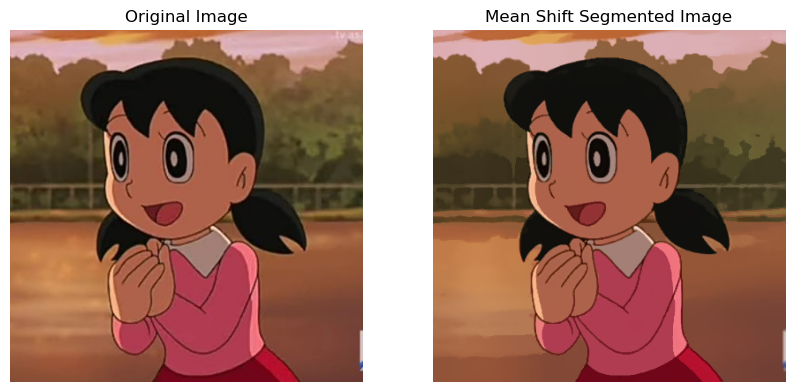

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread(r"C:\Users\rithi\Downloads\shizuka.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for visualization

# Apply Mean Shift Filtering
spatial_radius = 20  # Radius in spatial space (affects smoothness)
color_radius = 20   # Radius in color space (affects color grouping)
max_level = 1        # Maximum level of the pyramid used in filtering

# Perform mean shift filtering
mean_shift_result = cv2.pyrMeanShiftFiltering(image, spatial_radius, color_radius, max_level)

# Display original and Mean Shift segmented image
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(image_rgb), plt.title("Original Image")
plt.axis("off")
plt.subplot(122), plt.imshow(cv2.cvtColor(mean_shift_result, cv2.COLOR_BGR2RGB)), plt.title("Mean Shift Segmented Image")
plt.axis("off")
plt.show()


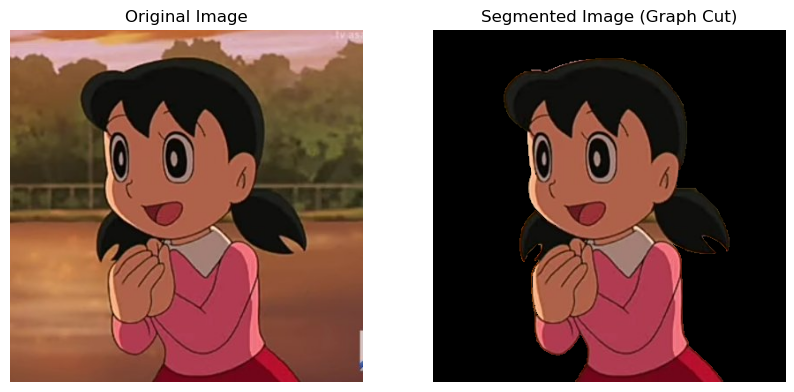

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread(r"C:\Users\rithi\Downloads\shizuka.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for displaying later

# Create mask and define background and foreground models
mask = np.zeros(image.shape[:2], dtype=np.uint8)  # Mask must be 0 for background and 1 for foreground
bg_model = np.zeros((1, 65), dtype=np.float64)  # Temporary arrays for background model
fg_model = np.zeros((1, 65), dtype=np.float64)  # Temporary arrays for foreground model

# Define a rectangle around the foreground object (modify according to your image)
rect = (1, 30, image.shape[1]-20, image.shape[0]-20)  # (x, y, width, height)

# Apply GrabCut with rectangle-based initialization
cv2.grabCut(image, mask, rect, bg_model, fg_model, iterCount=5, mode=cv2.GC_INIT_WITH_RECT)

# Modify the mask so it has 0, 1 values (0 = background, 1 = foreground)
# GrabCut creates a mask with values 0, 2 for sure background and 1, 3 for sure foreground
mask_result = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

# Apply mask to the image to get segmented foreground
segmented_image = image * mask_result[:, :, np.newaxis]  # Keep only the foreground region

# Display the original and segmented images
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(image_rgb), plt.title("Original Image")
plt.axis("off")
plt.subplot(122), plt.imshow(cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB)), plt.title("Segmented Image (Graph Cut)")
plt.axis("off")
plt.show()
